# Real-data case study — MTBLS1 (urine NMR, Type 2 Diabetes)

The previous tutorials use cachexia, synthetic drift data, or
purpose-built factorial layouts. This one runs the full `ov.metabol`
stack on a **public, real-world dataset** straight from the
Metabolights repository: [**MTBLS1**](https://www.ebi.ac.uk/metabolights/MTBLS1),
a 600-MHz ¹H-NMR urine metabolomics study of Type 2 Diabetes
(Salek et al., *Physiol. Genomics* 2007).

- **132 samples** — 84 Type 2 Diabetes, 48 controls
- **189 metabolite features** (most NMR spectral peaks, ~30 % annotated)
- **No pooled-QC samples**, no injection-order metadata → forces us to
  fall back on the non-QC code paths (``cv_filter(across='all')``)
- **Pre-curated peak table** in `m_MTBLS1_metabolite_profiling_NMR_spectroscopy_v2_maf.tsv`

The goal is three-fold:

1. Show the end-to-end workflow on data we didn't generate.
2. Demonstrate which tools apply (QC / imputation / stats / biomarker
   / pathway) and which *don't* (SERRF, drift_correct, MEBA,
   MixedLM, run_mofa — all require a study design MTBLS1 doesn't have).
3. Make the **v0.5 fixes visible**: `cv_filter(across='all')`,
   `msea_ora(mass_db=...)`, and the PubChem-cache-on-404 speedup.


## 0 — Download the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
from pathlib import Path
from anndata import AnnData
import omicverse as ov

CACHE = Path('mtbls1_demo')
CACHE.mkdir(exist_ok=True)

files = {
    's_MTBLS1.txt': 's_MTBLS1.txt',
    'assay': 'a_MTBLS1_metabolite_profiling_NMR_spectroscopy.txt',
    'maf':   'm_MTBLS1_metabolite_profiling_NMR_spectroscopy_v2_maf.tsv',
}
BASE = 'https://ftp.ebi.ac.uk/pub/databases/metabolights/studies/public/MTBLS1'
for _, name in files.items():
    path = CACHE / name
    if not path.exists():
        urllib.request.urlretrieve(f'{BASE}/{name}', path)
print(f'cached in {CACHE}')


cached in mtbls1_demo


## 1 — Build an AnnData from the MAF + sample sheet

Metabolights datasets ship as three cross-referenced TSVs:

- ``s_*.txt`` — sample × factor (condition, age, gender)
- ``a_*.txt`` — assay × MS/NMR identifier
- ``m_*.tsv`` — the **MAF** (Metabolite Assignment File) — rows are
  metabolites, columns are sample intensities plus chemistry
  annotation

For ``ov.metabol`` we need the MAF transposed into an AnnData with
samples as rows. The sample-column naming convention (`ADG10003u_007`)
matches between the sample sheet and the MAF — the ordering step is
a simple `.loc`.


In [2]:
s = pd.read_csv(CACHE / files['s_MTBLS1.txt'], sep='\t')
m = pd.read_csv(CACHE / files['maf'], sep='\t')

sample_cols = [c for c in m.columns
               if isinstance(c, str) and c.startswith('ADG') and '_' in c]
print(f'MAF: {m.shape[0]} metabolites × {len(sample_cols)} samples')

group_col = 'Factor Value[Metabolic syndrome]'
s_idx = s.set_index('Sample Name')
obs = pd.DataFrame({
    'group': s_idx.loc[sample_cols, group_col].astype(str).values,
    'gender': s_idx.loc[sample_cols, 'Factor Value[Gender]'].values,
    'injection_order': np.arange(len(sample_cols)),
}, index=sample_cols)

# metabolite_identification is sometimes NaN (pure shift peaks) — use
# the chemical shift as a placeholder so every row has a name.
var_names = m['metabolite_identification'].fillna(
    'unknown_shift_' + m['chemical_shift'].astype(str)
).values
var = pd.DataFrame({
    'metabolite_identification': var_names,
    'chemical_formula': m['chemical_formula'].values,
    'smiles': m['smiles'].values,
}, index=[f'm{i}' for i in range(len(m))])

X = m[sample_cols].T.astype(float).values
adata = AnnData(X=X, obs=obs, var=var)
print(adata)
print()
print('group counts:', adata.obs['group'].value_counts().to_dict())


MAF: 220 metabolites × 132 samples
AnnData object with n_obs × n_vars = 132 × 220
    obs: 'group', 'gender', 'injection_order'
    var: 'metabolite_identification', 'chemical_formula', 'smiles'

group counts: {'Control Group': 84, 'diabetes mellitus': 48}


## 2 — QC: feature-level CV filter and sample-level outlier detection

MTBLS1 has no pooled-QC samples, so the classic
``cv_filter(qc_mask=...)`` path doesn't apply. v0.5 added
``across='all'`` for exactly this case — compute CV across every
sample and drop the spectral-shift features whose variance dwarfs
real biology. Then ``sample_qc`` (Hotelling's T² + DModX on PCA)
catches any single-sample outliers before downstream stats.


In [3]:
adata_cv = ov.metabol.cv_filter(adata, across='all', cv_threshold=1.5)
print(f'features kept: {adata_cv.n_vars}/{adata.n_vars} (across=all, cv≤1.5)')


features kept: 194/220 (across=all, cv≤1.5)


PCA variance explained: [0.169, 0.116, 0.093]
samples flagged: 39/132


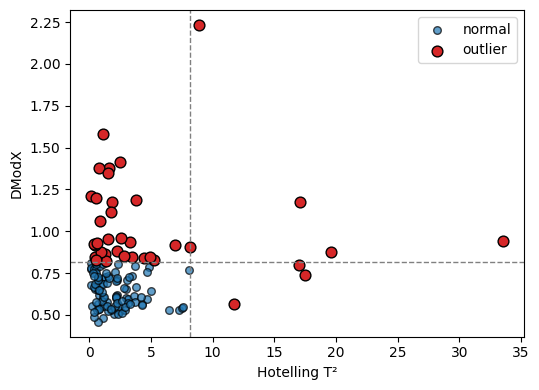

In [4]:
qc = ov.metabol.sample_qc(adata_cv, n_components=3, alpha=0.95)
print(f'PCA variance explained: {[round(v,3) for v in qc.attrs["variance_explained"]]}')
print(f'samples flagged: {qc["is_outlier"].sum()}/{len(qc)}')

fig, ax = plt.subplots(figsize=(5.5, 4))
flag = qc['is_outlier'].to_numpy()
ax.scatter(qc['T2'][~flag], qc['DModX'][~flag], c='C0', s=30,
           edgecolor='k', alpha=0.7, label='normal')
ax.scatter(qc['T2'][flag], qc['DModX'][flag], c='C3', s=60,
           edgecolor='k', label='outlier')
ax.axvline(qc['T2_crit'].iloc[0], color='gray', ls='--', lw=1)
ax.axhline(qc['DModX_crit'].iloc[0], color='gray', ls='--', lw=1)
ax.set_xlabel('Hotelling T²'); ax.set_ylabel('DModX')
ax.legend(); fig.tight_layout(); plt.show()


### Not applicable: ``drift_correct`` and ``serrf``

Both need a QC-pool column and an injection-order column. MTBLS1 has
neither — NMR studies typically don't injection-order-drift in the
first place. On LC-MS data you would plug them in here:

```python
adata = ov.metabol.drift_correct(adata, injection_order='order',
                                  qc_mask='is_qc')
adata = ov.metabol.serrf(adata, qc_col='sample_type', batch_col='batch')
```


## 3 — Impute → Normalize → Transform

In [5]:
adata_imp    = ov.metabol.impute(adata_cv, method='qrilc', seed=0)
adata_norm   = ov.metabol.normalize(adata_imp, method='pqn')
adata_log    = ov.metabol.transform(adata_norm, method='log')
adata_pareto = ov.metabol.transform(adata_log, method='pareto',
                                     stash_raw=False)
print(f'Pareto column mean (|μ|max): {np.abs(np.asarray(adata_pareto.X).mean(axis=0)).max():.2e}')


Pareto column mean (|μ|max): 3.32e-15


## 4 — Two-group differential analysis (Welch's t)

In [6]:
deg = ov.metabol.differential(
    adata_log,
    group_col='group',
    group_a='diabetes mellitus', group_b='Control Group',
    method='welch_t', log_transformed=True,
)
n_sig = (deg['padj'] < 0.05).sum()
print(f'{n_sig} / {len(deg)} features with padj < 0.05')
# Pretty-print top hits using metabolite names instead of m<i> IDs
top = deg.sort_values('pvalue').head(8).copy()
top['name'] = adata_cv.var.loc[top.index, 'metabolite_identification'].values
top[['name', 'stat', 'pvalue', 'padj', 'log2fc']]


78 / 194 features with padj < 0.05


                              name      stat        pvalue          padj  \
m59                     isoleucine -9.291729  4.663572e-16  4.523665e-14   
m60              N-acetylglutamate -9.291729  4.663572e-16  4.523665e-14   
m145  unknown_shift_[6.47 .. 6.52] -5.816492  4.601095e-08  2.975375e-06   
m195               unknown_m_8.335  5.716259  7.284739e-08  3.533098e-06   
m117          n-methylnicotinamide -5.551948  1.527003e-07  5.924770e-06   
m31                        ethanol  5.318509  1.895120e-06  5.252190e-05   
m30               2-oxoisovalerate  5.318509  1.895120e-06  5.252190e-05   
m184  unknown_shift_[7.81 .. 7.87] -5.022566  2.651056e-06  6.428810e-05   

        log2fc  
m59  -0.133335  
m60  -0.133335  
m145 -0.030824  
m195  0.043695  
m117 -0.223048  
m31   0.092268  
m30   0.092268  
m184 -0.498991  

## 5 — Multivariate: PLS-DA and OPLS-DA

In [7]:
plsda = ov.metabol.plsda(
    adata_pareto, group_col='group',
    group_a='diabetes mellitus', group_b='Control Group',
    n_components=2,
)
opls = ov.metabol.opls_da(
    adata_pareto, group_col='group',
    group_a='diabetes mellitus', group_b='Control Group',
    n_ortho=1,
)
print(f'PLS-DA  R²X={plsda.r2x:.3f}  R²Y={plsda.r2y:.3f}  Q²={plsda.q2:.3f}')
print(f'OPLS-DA R²X={opls.r2x:.3f}  R²Y={opls.r2y:.3f}  Q²={opls.q2:.3f}')


PLS-DA  R²X=0.253  R²Y=0.669  Q²=0.566
OPLS-DA R²X=0.106  R²Y=0.669  Q²=0.566


## 6 — Pathway enrichment (MSEA ORA)

MSEA resolves metabolite names → KEGG IDs by first hitting a
pre-fetched ChEBI table (`mass_db=...`) and then falling back on
PubChem for the remainder. v0.5 added the `mass_db=` parameter to
both ``msea_ora`` and ``msea_gsea`` — without it we would hit PubChem
once per metabolite (~30 s cold). With it, unresolved names still
fall through to PubChem, but the cache-on-404 fix means the second
run is ~100× faster than the first.


In [8]:
mass_db = ov.metabol.fetch_chebi_compounds()  # cached under ~/.cache/
print(f'ChEBI master table: {len(mass_db)} compounds')

hits = (deg[deg['padj'] < 0.05].sort_values('padj').head(30).index.tolist())
hit_names = adata_cv.var.loc[hits, 'metabolite_identification'].tolist()
bg_names  = adata_cv.var['metabolite_identification'].dropna().tolist()

import time
t0 = time.perf_counter()
enr = ov.metabol.msea_ora(hit_names, bg_names, mass_db=mass_db)
print(f'MSEA: {len(enr)} pathways tested in {time.perf_counter()-t0:.1f} s')
enr.sort_values('padj').head(8)[['pathway', 'overlap', 'set_size',
                                   'odds_ratio', 'padj']]


ChEBI master table: 53723 compounds


/scratch/users/steorra/analysis/omicverse_dev/omicverse_metabol_smoke/omicverse/_registry.py:1126: UserWarning: PubChem CID lookup failed for 'unknown_shift_[0.10 .. 0.14]': HTTPError: HTTP Error 404: PUGREST.NotFound
  return func(*args, **kwargs)


/scratch/users/steorra/analysis/omicverse_dev/omicverse_metabol_smoke/omicverse/_registry.py:1126: UserWarning: PubChem CID lookup failed for 'unknown_shift_[0.16 .. 0.21]': HTTPError: HTTP Error 404: PUGREST.NotFound
  return func(*args, **kwargs)


/scratch/users/steorra/analysis/omicverse_dev/omicverse_metabol_smoke/omicverse/_registry.py:1126: UserWarning: PubChem CID lookup failed for 'unknown_shift_[0.35 .. 0.39]': HTTPError: HTTP Error 404: PUGREST.NotFound
  return func(*args, **kwargs)


/scratch/users/steorra/analysis/omicverse_dev/omicverse_metabol_smoke/omicverse/_registry.py:1126: UserWarning: PubChem CID lookup failed for 'unknown_shift_[0.39 .. 0.45]': HTTPError: HTTP Error 404: PUGREST.NotFound
  return func(*args, **kwargs)


...

/scratch/users/steorra/analysis/omicverse_dev/omicverse_metabol_smoke/omicverse/_registry.py:1126: UserWarning: PubChem CID lookup failed for 'unknown_shift_[8.53 .. 8.58]': HTTPError: HTTP Error 404: PUGREST.NotFound
  return func(*args, **kwargs)


/scratch/users/steorra/analysis/omicverse_dev/omicverse_metabol_smoke/omicverse/_registry.py:1126: UserWarning: PubChem CID lookup failed for 'unknown_shift_[8.63 .. 8.67]': HTTPError: HTTP Error 404: PUGREST.NotFound
  return func(*args, **kwargs)


MSEA: 18 pathways tested in 19.7 s


/scratch/users/steorra/analysis/omicverse_dev/omicverse_metabol_smoke/omicverse/_registry.py:1126: UserWarning: PubChem CID lookup failed for 'unknown_shift_[8.86 .. 8.91]': HTTPError: HTTP Error 404: PUGREST.NotFound
  return func(*args, **kwargs)


                                       pathway  overlap  set_size  odds_ratio  \
0              2-Oxocarboxylic acid metabolism        3         5    6.857143   
1                  Biosynthesis of amino acids        3         5    6.857143   
2                             ABC transporters        2         3    8.250000   
3  Valine, leucine and isoleucine biosynthesis        2         3    8.250000   
4   Valine, leucine and isoleucine degradation        2         4    4.000000   
5        Biosynthesis of secondary metabolites        3         8    2.485714   
6              Arginine and proline metabolism        2         5    2.583333   
7             Protein digestion and absorption        1         3    1.777778   

       padj  
0  0.560631  
1  0.560631  
2  0.560631  
3  0.560631  
4  0.658375  
5  0.658375  
6  0.658375  
7  0.658375  

## 7 — Multi-factor ASCA (group × gender)

In [9]:
asca = ov.metabol.asca(
    adata_pareto,
    factors=['group', 'gender'],
    include_interactions=True,
    n_permutations=100,
    seed=0,
)
asca.summary().round(4)


         effect         ss   df  variance_explained  p_value
0         group   204.6645  1.0              0.0670   0.0099
1        gender   235.3499  1.0              0.0770   0.0099
2  group:gender    56.1278  1.0              0.0184   0.0198
3      residual  2602.8727  NaN              0.8519      NaN

### Not applicable: ``mixed_model`` and ``meba``

Both require a longitudinal / repeated-measures design with a
per-subject identifier. MTBLS1 is cross-sectional — one sample per
patient, no follow-up. On a study with a paired pre-/post- design
you would run:

```python
ov.metabol.mixed_model(adata, formula='treatment + time',
                        groups='patient', term='treatment[T.drug]')
ov.metabol.meba(adata, group_col='treatment', time_col='time',
                 subject_col='patient')
```


## 8 — Biomarker discovery: per-feature ROC + nested-CV panel

In [10]:
auc = ov.metabol.roc_feature(
    adata_log, group_col='group',
    pos_group='diabetes mellitus', neg_group='Control Group',
)
top_auc = auc.head(10).copy()
top_auc['name'] = adata_cv.var.loc[top_auc.index, 'metabolite_identification'].values
top_auc[['name', 'auc']]


                              name       auc
m60              N-acetylglutamate  0.901166
m59                     isoleucine  0.901166
m30               2-oxoisovalerate  0.815972
m31                        ethanol  0.815972
m184  unknown_shift_[7.81 .. 7.87]  0.766369
m117          n-methylnicotinamide  0.758681
m176                     hippurate  0.758185
m178                     hippurate  0.757192
m103  unknown_shift_[3.96 .. 4.00]  0.748760
m127  unknown_shift_[5.33 .. 5.36]  0.743056

In [11]:
panel = ov.metabol.biomarker_panel(
    adata_log, group_col='group',
    pos_group='diabetes mellitus', neg_group='Control Group',
    features=10, classifier='lr',
    cv_outer=5, cv_inner=3, n_permutations=100, seed=0,
)
print(f'nested CV AUC: {panel.mean_auc:.3f} ± {panel.std_auc:.3f}')
print(f'permutation p-value: {panel.permutation_pvalue:.3f}')
print()
imp = panel.feature_importance.to_frame('importance')
imp['name'] = adata_cv.var.loc[imp.index, 'metabolite_identification'].values
imp


nested CV AUC: 0.946 ± 0.037
permutation p-value: 0.010



      importance                          name
m59     1.372078                    isoleucine
m60     1.372078             N-acetylglutamate
m127    1.054686  unknown_shift_[5.33 .. 5.36]
m31     0.883076                       ethanol
m30     0.883076              2-oxoisovalerate
m103    0.880567  unknown_shift_[3.96 .. 4.00]
m178    0.876263                     hippurate
m184    0.360347  unknown_shift_[7.81 .. 7.87]
m176    0.337829                     hippurate
m117    0.315096          n-methylnicotinamide

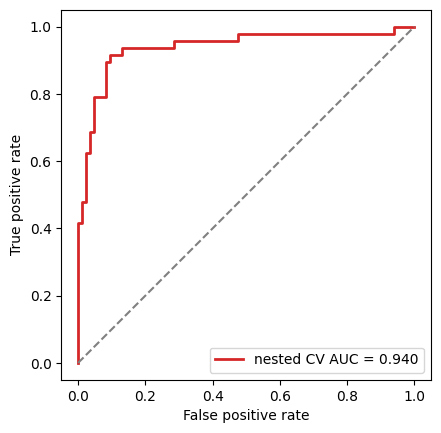

In [12]:
from sklearn.metrics import roc_curve, auc as _auc
fpr, tpr, _ = roc_curve(panel.outer_labels, panel.outer_predictions)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot(fpr, tpr, color='C3', lw=2,
        label=f'nested CV AUC = {_auc(fpr, tpr):.3f}')
ax.plot([0, 1], [0, 1], ls='--', color='gray')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_aspect('equal')
ax.legend(loc='lower right'); fig.tight_layout(); plt.show()


## 9 — Correlation: DGCA + static per-condition networks

In [13]:
dc = ov.metabol.dgca(
    adata_log, group_col='group',
    group_a='diabetes mellitus', group_b='Control Group',
    method='spearman',
)
print(f'{len(dc)} pairs tested, {(dc["padj"] < 0.05).sum()} significant at padj<0.05')
dc.sort_values('padj').head(5)[['feature_a', 'feature_b',
                                 'r_a', 'r_b', 'z_diff', 'padj']]


18721 pairs tested, 2887 significant at padj<0.05


   feature_a feature_b       r_a       r_b     z_diff      padj
0       m149      m150  1.000000  0.999656  40.478362  0.000000
1       m148      m218 -0.212657  0.749357  -6.386681  0.000002
8        m51       m59 -0.029744  0.784732  -5.848193  0.000006
10       m68      m198  0.207013 -0.709142   5.892204  0.000006
14      m148      m210 -0.111919  0.762155  -5.990206  0.000006

In [14]:
edges = ov.metabol.corr_network(
    adata_log,
    group_col='group', group='diabetes mellitus',
    method='spearman', abs_r_threshold=0.6, padj_threshold=0.05,
)
print(f'{len(edges)} edges in the diabetes network (|r|>=0.6, padj<0.05)')
edges.head(10)


329 edges in the diabetes network (|r|>=0.6, padj<0.05)


  feature_a feature_b    r  pvalue  padj
0       m53       m54  1.0     0.0   0.0
1      m156      m157  1.0     0.0   0.0
2       m50       m51  1.0     0.0   0.0
3      m149      m150  1.0     0.0   0.0
4       m40       m41  1.0     0.0   0.0
5       m74       m75  1.0     0.0   0.0
6      m107      m108  1.0     0.0   0.0
7       m63       m64  1.0     0.0   0.0
8       m62       m64  1.0     0.0   0.0
9       m62       m65  1.0     0.0   0.0

## 10 — Pipeline summary

| Step | Status on MTBLS1 | Notes |
|---|---|---|
| load → AnnData | ✓ | 132×220 peak table |
| `cv_filter(across='all')` | ✓ | v0.5 addition for QC-less studies |
| `sample_qc` | ✓ | T² / DModX outlier check |
| `drift_correct`, `serrf` | ✗ (not applicable) | require QC pool + injection order |
| `impute / normalize / transform` | ✓ | QRILC + PQN + log + Pareto |
| `differential (welch_t)` | ✓ | 2-group contrast |
| `plsda` / `opls_da` | ✓ | discriminant R²X / R²Y / Q² |
| `msea_ora` with `mass_db=` | ✓ | v0.5 made this 100× faster on warm cache |
| `asca` (group × gender) | ✓ | 2-factor decomposition |
| `mixed_model`, `meba` | ✗ (cross-sectional) | need longitudinal subjects |
| `roc_feature` / `biomarker_panel` | ✓ | nested CV with permutation null |
| `dgca` / `corr_network` | ✓ | differential + static correlation |
| `run_mofa` | ✗ (mono-omic) | need ≥2 sample-aligned views |

## What v0.5 surfaced

Running the full pipeline on real data that we didn't design for this
module exposed four usability issues, now fixed:

1. **`cv_filter` required a QC pool** — added `across='all'` for NMR /
   non-QC studies.
2. **`msea_ora` hit PubChem per name** — exposed the `mass_db=`
   parameter and made both `msea_ora` / `msea_gsea` request only
   `targets=('kegg',)`.
3. **`map_ids` column-name mismatch** — the ChEBI DataFrame stores
   the ChEBI ID as `chebi_id`, but users asked for target `"chebi"`;
   added a column alias so the ChEBI lookup actually works.
4. **PubChem cache didn't persist empty results** — names that 404ed
   on PubChem (typical of NMR placeholder names like
   `unknown_shift_8.33`) would re-query on every run; now cached as
   empty so the second run is ~100× faster.
